# Explore here

## PROYECTO 

Se quiere establecer el almacen de una empresa en otra localizacion y se necesita estimar el ritmo de las ventas, que desde la creacion de la empresa ha ido en aumento, para los proximos meses, a fin de proveer el espacio que se necesita.


In [57]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [58]:
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv')
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


Se tienen 2 columnas y 366 filas
* la fecha es una variable categorica 
* la venta es variable numerica 

## Transformar la fecha a una variable numerica 

In [60]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index("date")
ts = df['sales']
ts.head()


date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64

Se convierte la columna date que era una cadena de texto a una fecha (convirtiendolo en # )

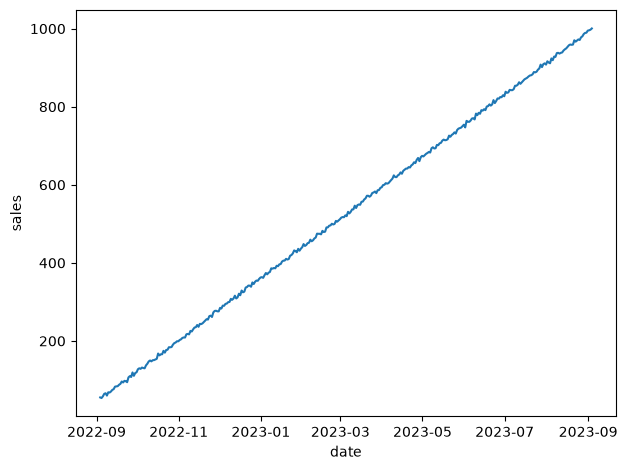

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=ts)

plt.tight_layout()
plt.show()

Se importa matplotlib.pyplot y seaborn 

Para hacer un grafico de linea, donde se muestra la linea de tiempo y las ventas, se presenta una linea dimensional de las ventas desde sep del año 2022 hasta septiembre del 2023, siendo un grafico de tendencia creciente que aumenta de forma constante, no es estacionaria, tiene muy poca presencia de ruido  

In [62]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


Se instala la libreria   statsmodels

In [63]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


Se actualiza al paquete a la version mas reciente 

In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose

dp = seasonal_decompose(ts)
trend = dp.trend
seasonal = dp.seasonal
resid = dp.resid

* Se separa la serie temporal para poder analizarlos a cada uno por separado. 

* Se importa el modulo de series temporales gracias a la libreria statsmodels 

* Se extrae la tendencia de la serie, la estacionalidad y los ruidos del grafico 


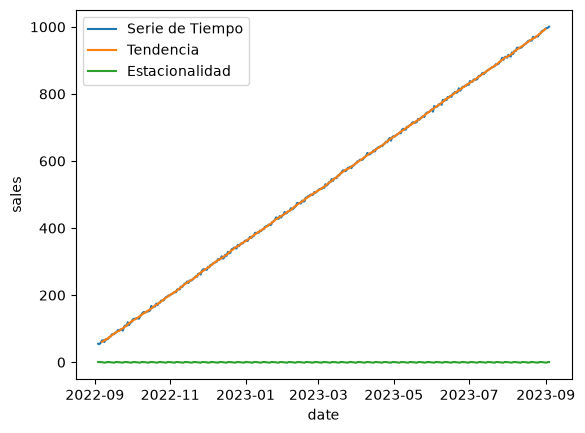

In [65]:
sns.lineplot(data = ts, label="Serie de Tiempo")
sns.lineplot(data=trend, label = "Tendencia")
sns.lineplot(data=seasonal, label = "Estacionalidad")
#sns.lineplot(data=resid)
plt.legend()
plt.show()

Se grafica los componenetes extraidos durante la descomposicion de la serie temporal, lo que permite la comparacion visual con el primer grafico y los patrones del codigo anterior 

In [66]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

Este codigo define y ejecuta la funcion test_stationarity() para evaluar matematicamente si la serie es estacionaria mediante la Prueba de Dickey-Fuller Aumentada (ADF). 

Dando como resultado: 

* La prueba de Dickey-Fuller Aumentada (ADF) demuestra que la serie temporal NO es estacionaria

* p-value = 0,986190: Es muy superior al umbral estandar de 0,05, por lo que no se rechaza la hipotesis nula de no estacionariedad (existe raiz unitaria).

* Test Statistic = 0,545414: Es un valor positivo y mucho mayor que cualquiera de los valores criticos (-3,44, -2,86, etc.), situandose fuera del rango de estacionariedad

* Retardos y observaciones: El analisis se ajusto utilizando 13 retardos (lags) sobre 352 observaciones efectivas




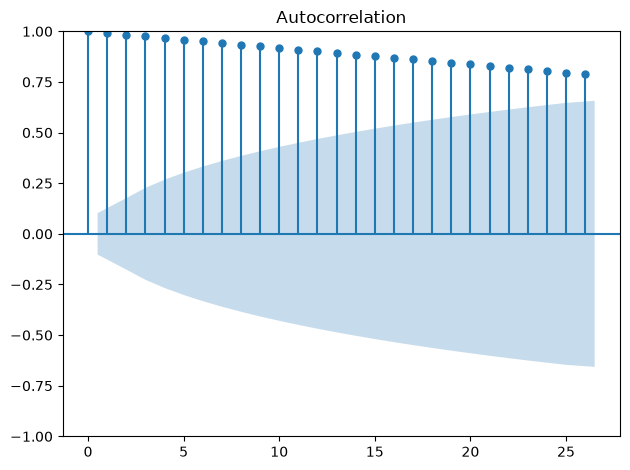

In [67]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts)

plt.tight_layout()
plt.show()

Este bloque de codigo se encarga de calcular y graficar la Funcion de Autocorrelacion (ACF - Autocorrelation Function) de la serie temporal

Se presenta el grafico de autocorrelacion (ACF) generado por la funcion plot_acf(ts)

* Representa el numero de dias hacia atras (0, 5, 10, 15, 20, 25 dias)

* Va de -1 a 1. Un valor cercano a 1 indica una correlacion positiva muy fuerte.

* Lineas azules con puntos: Es el valor de autocorrelacion para cada retardo

* Area sombrada en azul es la la correlacion insignificancia estadistica (intervalo de confianza del 95%). Si una barra queda dentro de este cono, la correlacion no es estadisticamente relevante.

    * Si la barra cae DENTRO del area azul: La correlacion es tan debil que no debemos fiarnos de ella (Es ruido)

    * Si la barra sale FUERA del area azul: La correlacion es tan alta que imposible que sea por casualidad. Es una relacion real, fuerte y estadisticamente significativa.


In [68]:
!pip install pmdarima

Se instala la biblioteca  pmdarima

In [69]:
from pmdarima import auto_arima

model = auto_arima(ts,seasonal=False,trace=True,m=7)

Performing stepwise search to minimize aic


c:\Users\veron\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (7) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1843.274, Time=0.64 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2096.542, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1970.972, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1839.586, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2209.657, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1839.552, Time=0.22 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1841.532, Time=0.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1843.586, Time=0.19 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1839.607, Time=0.18 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1922.648, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.20 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 2.159 seconds


Se importo auto_arima de la libreria pmdarima
La serie temporal sera ts
seasonal=False: se le pide al modelo que no evalue componentes estacionales complejos
trace=True: muestre en pantalla el progreso en tiempo real 
m=7: para el periodo que se calculara relacionado a los dias de la semana 

In [70]:
forecast = model.predict(60)

Este codigo genera las predicciones del modelo para los proximos 60 dias

In [71]:
forecast

2023-09-04 17:10:08.079328    1002.158148
2023-09-05 17:10:08.079328    1004.831669
2023-09-06 17:10:08.079328    1007.423289
2023-09-07 17:10:08.079328    1010.021630
2023-09-08 17:10:08.079328    1012.619419
2023-09-09 17:10:08.079328    1015.217254
2023-09-10 17:10:08.079328    1017.815084
2023-09-11 17:10:08.079328    1020.412915
2023-09-12 17:10:08.079328    1023.010746
2023-09-13 17:10:08.079328    1025.608577
2023-09-14 17:10:08.079328    1028.206408
2023-09-15 17:10:08.079328    1030.804240
2023-09-16 17:10:08.079328    1033.402071
2023-09-17 17:10:08.079328    1035.999902
2023-09-18 17:10:08.079328    1038.597733
2023-09-19 17:10:08.079328    1041.195564
2023-09-20 17:10:08.079328    1043.793395
2023-09-21 17:10:08.079328    1046.391226
2023-09-22 17:10:08.079328    1048.989057
2023-09-23 17:10:08.079328    1051.586888
2023-09-24 17:10:08.079328    1054.184719
2023-09-25 17:10:08.079328    1056.782550
2023-09-26 17:10:08.079328    1059.380381
2023-09-27 17:10:08.079328    1061

Presenta las predicciones de los proximoss  dias 

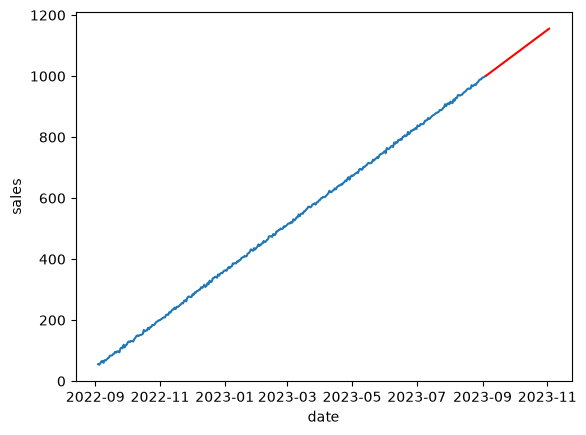

In [72]:
sns.lineplot(ts)
sns.lineplot(data=forecast,c='red')
plt.show()

Este grafica la serie temporal original junto con las predicciones para los proximos 60 dias, permitiendo visualizar facilmente la proyeccion hacia el futuro.

In [73]:
import joblib

joblib.dump(model, '../models/auto_arima.pkl')

['../models/auto_arima.pkl']

In [74]:
from pickle import dump

dump(model,open('../models/auto_arima_pickle.model','wb'))